In [4]:
import xarray as xr

lr_path = "/home/inhye_yoo/data/IMERG/Imerg_raw/imerg_merged_precip.nc"
path = "/home/inhye_yoo/inference_tools/imerg_liif/results/enc_ft/preds_not_merged/preds_daily_precip_IMERG_TOPO_100X100/pred_2017_2019_merged.nc"
ds = xr.open_dataset(path)
display(ds)

<xarray.Dataset>
Dimensions:  (time: 1095, lon: 100, lat: 100)
Coordinates:
  * time     (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2019-12-31
  * lon      (lon) float64 124.0 124.2 124.2 124.3 ... 133.7 133.8 133.8 133.9
  * lat      (lat) float64 42.95 42.85 42.75 42.65 ... 33.35 33.25 33.15 33.05
Data variables:
    precip   (time, lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jun 10 12:21:36 2026: cdo mergetime pred_2017-01-01.nc ...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib

# ── 한글 폰트 설정 ─────────────────────────────────────────────────────────────
font_candidates = [f.name for f in fm.fontManager.ttflist]
korean_fonts = [
    f for f in font_candidates
    if "Nanum" in f or "나눔" in f or "Malgun" in f or "맑은" in f
]

if korean_fonts:
    matplotlib.rc("font", family=korean_fonts[0])
else:
    matplotlib.rc("font", family="DejaVu Sans")

matplotlib.rcParams["axes.unicode_minus"] = False

# ── 경로 설정 ──────────────────────────────────────────────────────────────────
lr_path = "/home/inhye_yoo/data/IMERG/Imerg_raw/imerg_merged_precip.nc"
pred_path = (
    "/home/inhye_yoo/inference_tools/imerg_liif/results/enc_ft/"
    "preds_not_merged/preds_daily_precip_IMERG_TOPO_100X100/"
    "pred_2017_2019_merged.nc"
)

# ── 공간 범위 ──────────────────────────────────────────────────────────────────
lat_min_load, lat_max_load = 33, 43
lon_min_load, lon_max_load = 124, 134

lat_min_view, lat_max_view = 33, 38.5
lon_min_view, lon_max_view = 125, 130

# ── 계절 정의 ──────────────────────────────────────────────────────────────────
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

# ══════════════════════════════════════════════════════════════════════════════
# 1. PREDS 데이터 로드
# ══════════════════════════════════════════════════════════════════════════════
ds_pred = xr.open_dataset(pred_path)
da_pred = ds_pred["precip"].sel(time=slice("2017-01-01", "2019-12-31"))

if float(da_pred.lat[0]) > float(da_pred.lat[-1]):
    da_pred = da_pred.isel(lat=slice(None, None, -1))

print(f"PREDS: {da_pred.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. RAW & GT 데이터 로드
# ══════════════════════════════════════════════════════════════════════════════
ds_lr = xr.open_dataset(lr_path)
lat_asc = float(ds_lr.lat[0]) < float(ds_lr.lat[-1])

if lat_asc:
    da_lr_raw = ds_lr["precipitation"].sel(
        time=slice("2017-01-01", "2019-12-31"),
        lon=slice(lon_min_load, lon_max_load),
        lat=slice(lat_min_load, lat_max_load),
    )
else:
    da_lr_raw = ds_lr["precipitation"].sel(
        time=slice("2017-01-01", "2019-12-31"),
        lon=slice(lon_min_load, lon_max_load),
        lat=slice(lat_max_load, lat_min_load),
    )

if float(da_lr_raw.lat[0]) > float(da_lr_raw.lat[-1]):
    da_lr_raw = da_lr_raw.isel(lat=slice(None, None, -1))

da_lr_raw = da_lr_raw.load()
print(f"LR raw: {da_lr_raw.shape}")

# GT는 넓은 영역 그대로
da_gt = da_lr_raw.copy()

# RAW 50×50 생성
n_lon = da_lr_raw.sizes["lon"]
n_lat = da_lr_raw.sizes["lat"]

win_lon = max(1, n_lon // 50)
win_lat = max(1, n_lat // 50)

da_lr_50 = da_lr_raw.coarsen(
    lon=win_lon,
    lat=win_lat,
    boundary="trim"
).mean()

print(f"RAW 50x50: {da_lr_50.shape}  |  GT orig: {da_gt.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. 계절별 평균
# ══════════════════════════════════════════════════════════════════════════════
def seasonal_mean(da, months):
    return da.isel(time=da.time.dt.month.isin(months)).mean(dim="time")


raw_season = {
    s: seasonal_mean(da_lr_50, m)
    for s, m in seasons.items()
}

pred_season = {
    s: seasonal_mean(da_pred, m)
    for s, m in seasons.items()
}

gt_season = {
    s: seasonal_mean(da_gt, m)
    for s, m in seasons.items()
}

# ══════════════════════════════════════════════════════════════════════════════
# 4. 시각화
# ══════════════════════════════════════════════════════════════════════════════
VMIN, VMAX = 0, 10
CMAP = "turbo"
projection = ccrs.PlateCarree()
season_list = list(seasons.keys())

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(13, 17),
    subplot_kw={"projection": projection},
)

fig.subplots_adjust(
    top=0.96,
    hspace=0.12,
    wspace=0.08,
)

col_titles = [
    "RAW (IMERG 50×50)",
    "PREDS (LIIF 100×100)",
    "GT (IMERG 100×100)",
]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(
        title,
        fontsize=13,
        fontweight="bold",
        pad=6,
    )

for row, season in enumerate(season_list):
    data_list = [
        raw_season[season],
        pred_season[season],
        gt_season[season],
    ]

    for col, data in enumerate(data_list):
        ax = axes[row, col]

        ax.add_feature(
            cfeature.COASTLINE,
            linewidth=0.9,
            edgecolor="black",
        )
        ax.add_feature(
            cfeature.BORDERS,
            linewidth=0.5,
            edgecolor="black",
            linestyle="--",
        )

        ax.set_extent(
            [lon_min_view, lon_max_view, lat_min_view, lat_max_view],
            crs=projection,
        )

        gl = ax.gridlines(
            crs=projection,
            draw_labels=True,
            linewidth=0.3,
            color="gray",
            alpha=0.5,
            linestyle="--",
        )

        gl.xlocator = mticker.FixedLocator([125, 127, 129])
        gl.ylocator = mticker.FixedLocator([33, 35, 37, 38.5])

        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (col == 0)
        gl.bottom_labels = (row == 3)

        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}

        lons = data.lon.values
        lats = data.lat.values
        vals = data.values

        if data.dims[0] == "lon":
            vals = vals.T

        im = ax.pcolormesh(
            lons,
            lats,
            vals,
            vmin=VMIN,
            vmax=VMAX,
            cmap=CMAP,
            transform=projection,
            shading="nearest",
        )

        if col == 0:
            ax.text(
                -0.18,
                0.5,
                season,
                transform=ax.transAxes,
                fontsize=16,
                fontweight="bold",
                va="center",
                ha="center",
                rotation=90,
            )

    # ── 컬러바 ────────────────────────────────────────────────────────────────
    cbar = plt.colorbar(
        im,
        ax=axes[row, :],
        orientation="vertical",
        fraction=0.017,
        pad=0.02,
        extend="max",
    )

    cbar.set_label(
        "mm/day",
        fontsize=15,
        fontweight="bold",
        rotation=90,
        labelpad=10,
    )

    major_ticks = np.arange(VMIN, VMAX + 1, 2)
    minor_ticks = np.arange(VMIN, VMAX + 1, 1)

    cbar.set_ticks(major_ticks)
    cbar.set_ticklabels([str(int(t)) for t in major_ticks])

    cbar.ax.yaxis.set_minor_locator(
        mticker.FixedLocator(minor_ticks)
    )

    cbar.ax.tick_params(
        which="major",
        labelsize=12,
        length=5,
        width=1.0,
    )

    cbar.ax.tick_params(
        which="minor",
        length=3,
        width=0.8,
    )

fig.suptitle(
    "Seasonal Mean Precipitation (2017–2019)",
    fontsize=16,
    fontweight="bold",
)

out_path = "/home/inhye_yoo/seasonal_precip_raw_preds_gt.png"

plt.savefig(
    out_path,
    dpi=150,
    bbox_inches="tight",
    facecolor="white",
)

plt.close()

print(f"\n✅ 저장 완료: {out_path}")

PREDS: (1095, 100, 100)
LR raw: (1095, 100, 100)
RAW 50x50: (1095, 50, 50)  |  GT orig: (1095, 100, 100)

✅ 저장 완료: /home/inhye_yoo/seasonal_precip_raw_preds_gt.png


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import matplotlib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import pearsonr
from skimage.metrics import structural_similarity as ssim_func

# ==============================================================================
# Font setup
# ==============================================================================
font_candidates = [f.name for f in fm.fontManager.ttflist]
korean_fonts = [f for f in font_candidates if "Nanum" in f or "Malgun" in f]
matplotlib.rc("font", family=korean_fonts[0] if korean_fonts else "DejaVu Sans")
matplotlib.rcParams["axes.unicode_minus"] = False

# ==============================================================================
# Paths / settings
# ==============================================================================
lr_path = "/home/inhye_yoo/data/IMERG/Imerg_raw/imerg_merged_precip.nc"
pred_path = (
    "/home/inhye_yoo/inference_tools/imerg_liif/results/enc_ft/"
    "preds_not_merged/preds_daily_precip_IMERG_TOPO_100X100_periodminmax/"
    "pred_2017_2019_merged.nc"
)

lat_min, lat_max = 33, 43
lon_min, lon_max = 124, 134
H_hr, W_hr = 100, 100

seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

# ==============================================================================
# Helpers
# ==============================================================================
def standardize_tlatlon(da):
    """Make sure DataArray is ordered as (time, lat, lon)."""
    if not all(d in da.dims for d in ["time", "lat", "lon"]):
        raise ValueError(f"Expected dims containing time/lat/lon, got {da.dims}")
    return da.transpose("time", "lat", "lon")


def ensure_ascending_coords(da):
    """Sort lat/lon ascending if needed."""
    if float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")
    if float(da.lon[0]) > float(da.lon[-1]):
        da = da.sortby("lon")
    return da


def get_season_vals(da, months):
    mask = da.time.dt.month.isin(months)
    return da.isel(time=mask).values  # (T, lat, lon)


def daily_mae(pred2d, gt2d):
    return float(np.nanmean(np.abs(pred2d - gt2d)))


def daily_rmse(pred2d, gt2d):
    return float(np.sqrt(np.nanmean((pred2d - gt2d) ** 2)))


def daily_pcc(pred2d, gt2d):
    p = pred2d.flatten()
    g = gt2d.flatten()
    mask = ~(np.isnan(p) | np.isnan(g))
    if mask.sum() < 3:
        return np.nan
    r, _ = pearsonr(p[mask], g[mask])
    return float(r)


def daily_ssim(pred2d, gt2d):
    p = np.asarray(pred2d, dtype=np.float32)
    g = np.asarray(gt2d, dtype=np.float32)

    # NaN 공통 마스크
    mask = ~(np.isnan(p) | np.isnan(g))

    # 유효값이 너무 적으면 계산 불가
    if mask.sum() < 10:
        return np.nan

    # NaN은 0으로 채우되, data_range는 유효값 기준으로 계산
    p_valid = p[mask]
    g_valid = g[mask]

    data_min = min(np.min(p_valid), np.min(g_valid))
    data_max = max(np.max(p_valid), np.max(g_valid))
    data_range = data_max - data_min

    # 완전히 같은 값만 있는 날: SSIM 계산 불안정
    if data_range == 0:
        return np.nan

    p_fill = np.where(mask, p, 0.0)
    g_fill = np.where(mask, g, 0.0)

    return float(ssim_func(
        g_fill,
        p_fill,
        data_range=data_range
    ))


def daily_mae_2d(arr, gt):
    return np.nanmean(np.abs(arr - gt), axis=0)


def daily_pcc_2d(arr, gt):
    n_t, n_lat, n_lon = arr.shape
    pcc_map = np.full((n_lat, n_lon), np.nan)
    for i in range(n_lat):
        for j in range(n_lon):
            p = arr[:, i, j]
            g = gt[:, i, j]
            mask = ~(np.isnan(p) | np.isnan(g))
            if mask.sum() > 2:
                r, _ = pearsonr(p[mask], g[mask])
                pcc_map[i, j] = r
    return pcc_map

# ==============================================================================
# Load PREDS
# ==============================================================================
ds_pred = xr.open_dataset(pred_path)
da_pred = ds_pred["precip"].sel(time=slice("2017-01-01", "2019-12-31"))

# 꼭 (time, lat, lon)으로 통일
da_pred = standardize_tlatlon(da_pred)
da_pred = ensure_ascending_coords(da_pred)

# 메모리로 올려서 lock/back-end 문제 방지
da_pred = da_pred.load()

print(f"PREDS: {da_pred.dims}, shape={da_pred.shape}")
print(f"PREDS lat: {float(da_pred.lat[0]):.3f} ~ {float(da_pred.lat[-1]):.3f}")
print(f"PREDS lon: {float(da_pred.lon[0]):.3f} ~ {float(da_pred.lon[-1]):.3f}")

# ==============================================================================
# Load GT / RAW from IMERG
# ==============================================================================
ds_lr = xr.open_dataset(lr_path)

# 먼저 region/time subset
da_lr = ds_lr["precipitation"].sel(
    time=slice("2017-01-01", "2019-12-31"),
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max),
)

# 현재 IMERG는 (time, lon, lat) 이므로 transpose 필요
# 만약 이미 (time, lat, lon)이면 그대로 유지
if da_lr.dims == ("time", "lon", "lat"):
    da_lr = da_lr.transpose("time", "lat", "lon")
else:
    da_lr = standardize_tlatlon(da_lr)

da_lr = ensure_ascending_coords(da_lr)

# interp 전에 load 해서 backend lock 문제 방지
da_lr = da_lr.load()

print(f"LR: {da_lr.dims}, shape={da_lr.shape}")
print(f"LR lat: {float(da_lr.lat[0]):.3f} ~ {float(da_lr.lat[-1]):.3f}")
print(f"LR lon: {float(da_lr.lon[0]):.3f} ~ {float(da_lr.lon[-1]):.3f}")

# ==============================================================================
# Target grid (100x100)
# ==============================================================================
target_lat = xr.DataArray(
    np.linspace(float(da_lr.lat[0]), float(da_lr.lat[-1]), H_hr),
    dims="lat",
    name="lat",
)
target_lon = xr.DataArray(
    np.linspace(float(da_lr.lon[0]), float(da_lr.lon[-1]), W_hr),
    dims="lon",
    name="lon",
)

# ==============================================================================
# GT / RAW on 100x100
# ==============================================================================
da_gt = da_lr.interp(lat=target_lat, lon=target_lon, method="linear")
da_gt = standardize_tlatlon(da_gt).load()

# RAW: coarsen then interpolate to 100x100
win_lat = max(1, da_lr.sizes["lat"] // 50)
win_lon = max(1, da_lr.sizes["lon"] // 50)

da_raw = da_lr.coarsen(lat=win_lat, lon=win_lon, boundary="trim").mean()
da_raw = da_raw.interp(lat=target_lat, lon=target_lon, method="linear")
da_raw = standardize_tlatlon(da_raw).load()

# PREDS: target grid로 맞추기
da_pred = da_pred.interp(lat=target_lat, lon=target_lon, method="linear")
da_pred = standardize_tlatlon(da_pred).load()

# ==============================================================================
# Align time
# ==============================================================================
da_gt, da_raw, da_pred = xr.align(da_gt, da_raw, da_pred, join="inner")

print("\n[Aligned shapes]")
print(f"GT   : {da_gt.dims}, shape={da_gt.shape}")
print(f"RAW  : {da_raw.dims}, shape={da_raw.shape}")
print(f"PREDS: {da_pred.dims}, shape={da_pred.shape}")

# ==============================================================================
# Quick check
# ==============================================================================
t0 = 0
print(f"\n[Day-0 mean]")
print(f"GT   : {float(da_gt.isel(time=t0).mean()):.4f} mm/day")
print(f"RAW  : {float(da_raw.isel(time=t0).mean()):.4f} mm/day")
print(f"PREDS: {float(da_pred.isel(time=t0).mean()):.4f} mm/day")

# ==============================================================================
# Seasonal metrics
# ==============================================================================
metrics = {"RAW": {}, "PREDS": {}}
season_list = list(seasons.keys())

print("\n" + "=" * 72)
print(f"{'Pair':>12}  {'Season':>6}  {'MAE':>7}  {'RMSE':>7}  {'PCC':>7}  {'SSIM':>7}  {'N':>5}")
print("=" * 72)

for s, months in seasons.items():
    gt_s = get_season_vals(da_gt, months)
    raw_s = get_season_vals(da_raw, months)
    pred_s = get_season_vals(da_pred, months)

    T = min(gt_s.shape[0], raw_s.shape[0], pred_s.shape[0])
    gt_s = gt_s[:T]
    raw_s = raw_s[:T]
    pred_s = pred_s[:T]

    for tag, arr in [("RAW", raw_s), ("PREDS", pred_s)]:
        mae_list = []
        rmse_list = []
        pcc_list = []
        ssim_list = []

        for t in range(T):
            mae_list.append(daily_mae(arr[t], gt_s[t]))
            rmse_list.append(daily_rmse(arr[t], gt_s[t]))
            pcc_list.append(daily_pcc(arr[t], gt_s[t]))
            ssim_list.append(daily_ssim(arr[t], gt_s[t]))

        mae_m = float(np.nanmean(mae_list))
        rmse_m = float(np.nanmean(rmse_list))
        pcc_m = float(np.nanmean(pcc_list))
        ssim_m = float(np.nanmean(ssim_list))

        metrics[tag][s] = dict(MAE=mae_m, RMSE=rmse_m, PCC=pcc_m, SSIM=ssim_m)
        print(f"{tag+' vs GT':>12}  {s:>6}  {mae_m:7.4f}  {rmse_m:7.4f}  {pcc_m:7.4f}  {ssim_m:7.4f}  {T:>5}")

    print("-" * 72)

print("=" * 72)

# ==============================================================================
# Spatial distribution maps
# ==============================================================================
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=4, ncols=4, figsize=(16, 17),
    subplot_kw={"projection": projection}
)
fig.subplots_adjust(top=0.95, hspace=0.12, wspace=0.12)

col_titles = ["RAW vs GT  (MAE)", "PREDS vs GT  (MAE)",
              "RAW vs GT  (PCC)", "PREDS vs GT  (PCC)"]
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontsize=10, fontweight="bold", pad=6)

mae_vmax = 3.0

lons = target_lon.values
lats = target_lat.values

for row, season in enumerate(season_list):
    gt_s = get_season_vals(da_gt, seasons[season])
    raw_s = get_season_vals(da_raw, seasons[season])
    pred_s = get_season_vals(da_pred, seasons[season])

    T = min(gt_s.shape[0], raw_s.shape[0], pred_s.shape[0])
    gt_s = gt_s[:T]
    raw_s = raw_s[:T]
    pred_s = pred_s[:T]

    mae_raw = daily_mae_2d(raw_s, gt_s)
    mae_pred = daily_mae_2d(pred_s, gt_s)
    pcc_raw = daily_pcc_2d(raw_s, gt_s)
    pcc_pred = daily_pcc_2d(pred_s, gt_s)

    maps = [mae_raw, mae_pred, pcc_raw, pcc_pred]
    cmaps = ["Reds", "Reds", "RdYlGn", "RdYlGn"]
    vmins = [0, 0, 0.0, 0.0]
    vmaxs = [mae_vmax, mae_vmax, 1.0, 1.0]

    for col, (data2d, cmap, vmin, vmax) in enumerate(zip(maps, cmaps, vmins, vmaxs)):
        ax = axes[row, col]
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="black", linestyle="--")
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)

        gl = ax.gridlines(
            crs=projection, draw_labels=True,
            linewidth=0.3, color="gray", alpha=0.4, linestyle="--"
        )
        gl.xlocator = mticker.FixedLocator([124, 127, 130, 133])
        gl.ylocator = mticker.FixedLocator([33, 36, 39, 42])
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (col == 0)
        gl.bottom_labels = (row == 3)
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        im = ax.pcolormesh(
            lons, lats, data2d,
            vmin=vmin, vmax=vmax,
            cmap=cmap, transform=projection, shading="auto"
        )

        if col == 0:
            ax.text(
                -0.20, 0.5, season, transform=ax.transAxes,
                fontsize=13, fontweight="bold",
                va="center", ha="center", rotation=90
            )

        if col in [1, 3]:
            label = "mm/day" if col == 1 else "r"
            cbar = plt.colorbar(
                im, ax=axes[row, col-1:col+1],
                orientation="vertical",
                fraction=0.025, pad=0.02, extend="both"
            )
            cbar.set_label(label, fontsize=8, rotation=90, labelpad=3)
            cbar.ax.tick_params(labelsize=7)

fig.suptitle(
    "Spatial Distribution: MAE & PCC  (RAW vs GT / PREDS vs GT,  2017-2019)",
    fontsize=12, fontweight="bold"
)
out_map = "/home/inhye_yoo/metrics_spatial_map.png"
plt.savefig(out_map, dpi=150, bbox_inches="tight", facecolor="white")
plt.close()
print(f"\n[Saved] {out_map}")

# ==============================================================================
# Bar chart
# ==============================================================================
metric_names = ["MAE", "RMSE", "PCC", "SSIM"]
fig2, axes2 = plt.subplots(1, 4, figsize=(14, 4))
fig2.subplots_adjust(wspace=0.35)

for ax, m in zip(axes2, metric_names):
    raw_vals = [metrics["RAW"][s][m] for s in season_list]
    pred_vals = [metrics["PREDS"][s][m] for s in season_list]
    x = np.arange(len(season_list))
    w = 0.35

    ax.bar(x - w/2, raw_vals, w, label="RAW vs GT", alpha=0.85)
    ax.bar(x + w/2, pred_vals, w, label="PREDS vs GT", alpha=0.85)

    ax.set_title(m, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(season_list)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    ax.set_xlabel("Season")
    ax.set_ylabel(m)

fig2.suptitle(
    "Seasonal Metrics (daily avg)  RAW vs GT / PREDS vs GT  2017-2019",
    fontsize=13, fontweight="bold"
)
out_bar = "/home/inhye_yoo/metrics_bar_chart.png"
plt.savefig(out_bar, dpi=150, bbox_inches="tight", facecolor="white")
plt.close()
print(f"[Saved] {out_bar}")

PREDS: ('time', 'lat', 'lon'), shape=(1095, 100, 100)
PREDS lat: 33.050 ~ 42.950
PREDS lon: 124.050 ~ 133.950
LR: ('time', 'lat', 'lon'), shape=(1095, 100, 100)
LR lat: 33.050 ~ 42.950
LR lon: 124.050 ~ 133.950

[Aligned shapes]
GT   : ('time', 'lat', 'lon'), shape=(1095, 100, 100)
RAW  : ('time', 'lat', 'lon'), shape=(1095, 100, 100)
PREDS: ('time', 'lat', 'lon'), shape=(1095, 100, 100)

[Day-0 mean]
GT   : 0.4836 mm/day
RAW  : 0.4908 mm/day
PREDS: 0.3531 mm/day

        Pair  Season      MAE     RMSE      PCC     SSIM      N
   RAW vs GT     DJF   0.1816   0.4130   0.9475   0.9274    270
 PREDS vs GT     DJF   0.2241   0.4723   0.9083   0.8104    270
------------------------------------------------------------------------
   RAW vs GT     MAM   0.2610   0.5830   0.9346   0.9371    276
 PREDS vs GT     MAM   0.2867   0.5990   0.8797   0.8611    276
------------------------------------------------------------------------
   RAW vs GT     JJA   0.6182   1.4462   0.9638   0.9508    276
 

/tmp/ipykernel_1741326/2762974728.py:117: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(arr - gt), axis=0)
/tmp/ipykernel_1741326/2762974728.py:117: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(arr - gt), axis=0)
/tmp/ipykernel_1741326/2762974728.py:117: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(arr - gt), axis=0)
/tmp/ipykernel_1741326/2762974728.py:117: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(arr - gt), axis=0)



[Saved] /home/inhye_yoo/metrics_spatial_map.png
[Saved] /home/inhye_yoo/metrics_bar_chart.png


In [12]:
# ==============================================================================
# Monthly mean time series: GT vs PREDS
# ==============================================================================
gt_monthly = da_gt.mean(dim=["lat", "lon"]).resample(time="1MS").mean()
pred_monthly = da_pred.mean(dim=["lat", "lon"]).resample(time="1MS").mean()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    gt_monthly.time,
    gt_monthly.values,
    label="GT (IMERG)",
    linewidth=1.8,
    color="black",
)

ax.plot(
    pred_monthly.time,
    pred_monthly.values,
    label="PREDS (100x100)",
    linewidth=1.6,
    color="red",
    alpha=0.85,
)

ax.set_title("Monthly Mean Precipitation (2017–2019)", fontsize=13, fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Precipitation (mm/day)")
ax.grid(True, alpha=0.3)
ax.legend()

# 보기 좋게 3개월 간격으로 tick 설정
ax.xaxis.set_major_locator(mticker.MaxNLocator(12))
fig.autofmt_xdate()

out_ts = "/home/inhye_yoo/monthly_mean_gt_vs_preds.png"
plt.tight_layout()
plt.savefig(out_ts, dpi=150, bbox_inches="tight", facecolor="white")
plt.close()

print(f"[Saved] {out_ts}")

[Saved] /home/inhye_yoo/monthly_mean_gt_vs_preds.png


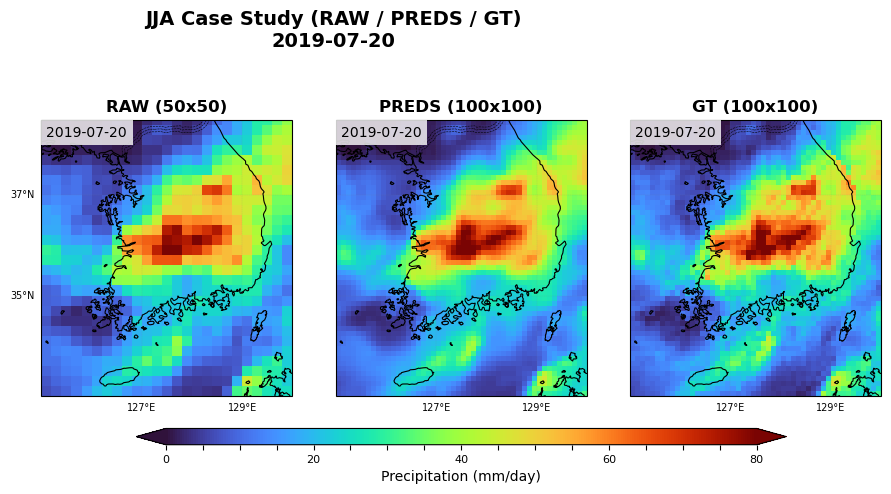

In [12]:
# ==============================================================================
# JJA Case Study: one day maps (RAW 50x50 / PREDS 100x100 / GT 100x100)
# ==============================================================================

import pandas as pd

# 1) 날짜 고정
case_time = np.datetime64("2019-07-20")
case_str = "2019-07-20"

# 남한 영역
lon_min, lon_max = 125, 130
lat_min, lat_max = 33, 38.5

# 2) RAW 50x50 만들기
win_lat = max(1, da_lr.sizes["lat"] // 50)
win_lon = max(1, da_lr.sizes["lon"] // 50)
da_raw_50 = da_lr.coarsen(lat=win_lat, lon=win_lon, boundary="trim").mean()

# 3) 해당 날짜의 field
gt_day   = da_gt.sel(time=case_time)        # 100x100
pred_day = da_pred.sel(time=case_time)      # 100x100
raw_day  = da_raw_50.sel(time=case_time)    # 50x50

# 추가
gt_day   = gt_day.transpose("lat", "lon")
pred_day = pred_day.transpose("lat", "lon")
raw_day  = raw_day.transpose("lat", "lon")

# 4) 색상 범위 고정
vmin = 0
vmax = 100

# 5) Plot
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 3,
    figsize=(17, 5),
    subplot_kw={"projection": projection}
)

fig.subplots_adjust(
    left=0.3,
    right=0.85,
    top=0.83,
    bottom=0.18,
    wspace=-0.15
)

plot_items = [
    ("RAW (50x50)",   raw_day),
    ("PREDS (100x100)", pred_day),
    ("GT (100x100)",  gt_day),
]

for i, (ax, (title, da2d)) in enumerate(zip(axes, plot_items)):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="black", linestyle="--")

    gl = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.25,
        color="gray",
        alpha=0.35,
        linestyle="--"
    )
    gl.xlocator = mticker.FixedLocator([125, 127, 129])
    gl.ylocator = mticker.FixedLocator([33, 35, 37, 38.5])
    gl.top_labels    = False
    gl.right_labels  = False
    gl.left_labels   = (i == 0)
    gl.bottom_labels = True
    gl.xlabel_style  = {"size": 7}
    gl.ylabel_style  = {"size": 7}

    im = ax.pcolormesh(
        da2d.lon.values,
        da2d.lat.values,
        da2d.values,
        transform=projection,
        shading="nearest",
        cmap="turbo",
        vmin=vmin,
        vmax=80,
    )

    ax.set_title(title, fontsize=12, fontweight="bold")

    ax.text(
        0.02, 0.98,
        case_str,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

# 6) colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.10,
    aspect=40,
    extend="both"
)
cbar.set_label("Precipitation (mm/day)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

cbar.set_ticks(np.arange(0, 81, 5))
cbar.set_ticklabels([str(v) if v % 20 == 0 else "" for v in np.arange(0, 81, 5)])

fig.suptitle(
    f"JJA Case Study (RAW / PREDS / GT)\n{case_str}",
    fontsize=14,
    fontweight="bold",
    y=1.05,
    x=0.5
)

plt.show()

In [28]:

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from PIL import Image
 
lr_path   = "/home/inhye_yoo/data/IMERG/Imerg_raw/imerg_merged_precip.nc"
pred_path = (
    "/home/inhye_yoo/inference_tools/imerg_liif/results/enc_ft/"
    "preds_not_merged/preds_daily_precip_IMERG_TOPO_100X100_periodminmax/"
    "pred_2017_2019_merged.nc"
)
 
lat_min, lat_max = 33, 43
lon_min, lon_max = 124, 134
H_hr, W_hr = 100, 100
H_lr, W_lr = 50, 50
 
CHECK_DATE = "2017-07-15"
 
# ── ds_slice (추론 코드와 동일) ──────────────────────────────────────────────
def ds_slice(xr_ds, date, lat_min, lat_max, lon_min, lon_max):
    var = "precipitation"
    da  = xr_ds[var]
    lat_name = "latitude" if "latitude" in da.coords else "lat"
    lon_name = "longitude" if "longitude" in da.coords else "lon"
    sub = da.where(
        (da[lat_name] >= lat_min) & (da[lat_name] <= lat_max) &
        (da[lon_name] >= lon_min) & (da[lon_name] <= lon_max),
        drop=True
    )
    d = pd.Timestamp(date)
    try:
        sub_t = sub.sel(time=d)
    except Exception:
        sub_t = sub.sel(time=d, method="nearest", tolerance=np.timedelta64(1, "D"))
    sub_t = sub_t.sortby(lat_name, ascending=False)
    if tuple(sub_t.dims[-2:]) != (lat_name, lon_name):
        sub_t = sub_t.transpose(..., lat_name, lon_name)
    arr = np.nan_to_num(sub_t.values, nan=0.0).astype(np.float32)
    return arr
 
# pixel-center 그리드 (내림차순)
lat_res     = (lat_max - lat_min) / H_hr
lon_res     = (lon_max - lon_min) / W_hr
lat_hr_desc = np.array([lat_max - (i + 0.5) * lat_res for i in range(H_hr)])
lon_hr      = np.array([lon_min + (j + 0.5) * lon_res for j in range(W_hr)])
 
# ── GT ───────────────────────────────────────────────────────────────────────
ds_lr  = xr.open_dataset(lr_path)
arr    = ds_slice(ds_lr, CHECK_DATE, lat_min, lat_max, lon_min, lon_max)
pil_gt = Image.fromarray(arr).resize((W_hr, H_hr), resample=Image.BILINEAR)
gt_2d  = np.array(pil_gt, dtype=np.float32)
 
# ── RAW (50x50 → 100x100) ────────────────────────────────────────────────────
pil_lr  = Image.fromarray(arr).resize((W_lr, H_lr), resample=Image.BILINEAR)
pil_raw = pil_lr.resize((W_hr, H_hr), resample=Image.BILINEAR)
raw_2d  = np.array(pil_raw, dtype=np.float32)
 
# ── PREDS ────────────────────────────────────────────────────────────────────
ds_pred  = xr.open_dataset(pred_path)
da_pred  = ds_pred["precip"].sel(time=CHECK_DATE)
if float(da_pred.lat[0]) < float(da_pred.lat[-1]):
    da_pred = da_pred.isel(lat=slice(None, None, -1))
pred_2d  = da_pred.values
 
print(f"date : {CHECK_DATE}")
print(f"GT   mean={gt_2d.mean():.3f}  max={gt_2d.max():.3f}")
print(f"RAW  mean={raw_2d.mean():.3f}  max={raw_2d.max():.3f}")
print(f"PRED mean={pred_2d.mean():.3f}  max={pred_2d.max():.3f}")
 
# ── 3개 지도 그리기 ───────────────────────────────────────────────────────────
projection = ccrs.PlateCarree()
fig, axes  = plt.subplots(1, 3, figsize=(13, 5),
                           subplot_kw={"projection": projection})
fig.subplots_adjust(wspace=0.12)
 
titles = [f"GT  ({CHECK_DATE})", f"RAW (50×50→100×100)", f"PREDS (LIIF 100×100)"]
data   = [gt_2d, raw_2d, pred_2d]
VMIN, VMAX = 0, 15
 
for ax, title, d2d in zip(axes, titles, data):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.9, edgecolor="black")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, edgecolor="black", linestyle="--")
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
 
    gl = ax.gridlines(crs=projection, draw_labels=True,
                      linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.xlocator = mticker.FixedLocator([124, 127, 130, 133])
    gl.ylocator = mticker.FixedLocator([33, 36, 39, 42])
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 7}; gl.ylabel_style = {"size": 7}
 
    im = ax.pcolormesh(lon_hr, lat_hr_desc, d2d,
                       vmin=VMIN, vmax=VMAX,
                       cmap="jet", transform=projection, shading="auto")
 
cbar = plt.colorbar(im, ax=axes, orientation="vertical",
                    fraction=0.015, pad=0.02, extend="max")
cbar.set_label("mm/day", fontsize=10, rotation=90)
cbar.ax.tick_params(labelsize=8)
 
fig.suptitle(f"Precipitation  {CHECK_DATE}  —  GT / RAW / PREDS",
             fontsize=13, fontweight="bold")
 
out = "/home/inhye_yoo/oneday_gt_raw_preds.png"
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
plt.close()
print(f"\n[Saved] {out}")

date : 2017-07-15
GT   mean=5.839  max=107.765
RAW  mean=5.839  max=86.976
PRED mean=5.720  max=100.546

[Saved] /home/inhye_yoo/oneday_gt_raw_preds.png


In [22]:
import xarray as xr
import numpy as np
 
lr_path   = "/home/inhye_yoo/data/IMERG/Imerg_raw/imerg_merged_precip.nc"
pred_path = (
    "/home/inhye_yoo/inference_tools/imerg_liif/results/enc_ft/"
    "preds_not_merged/preds_daily_precip_IMERG_TOPO_100X100_periodminmax/"
    "pred_2017_2019_merged.nc"
)
 
lat_min, lat_max = 33, 43
lon_min, lon_max = 124, 134
 
# GT (lr_path 한반도 영역)
ds_lr = xr.open_dataset(lr_path)
lat_asc = float(ds_lr.lat[0]) < float(ds_lr.lat[-1])
if lat_asc:
    da_gt = ds_lr["precipitation"].sel(
        time=slice("2017-01-01", "2019-12-31"),
        lon=slice(lon_min, lon_max),
        lat=slice(lat_min, lat_max))
else:
    da_gt = ds_lr["precipitation"].sel(
        time=slice("2017-01-01", "2019-12-31"),
        lon=slice(lon_min, lon_max),
        lat=slice(lat_max, lat_min))
 
gt_vals = da_gt.values
 
# PREDS
ds_pred = xr.open_dataset(pred_path)
da_pred = ds_pred["precip"].sel(time=slice("2017-01-01", "2019-12-31"))
pred_vals = da_pred.values
 
print("="*45)
print(f"{'':10}  {'min':>8}  {'mean':>8}  {'99th':>8}  {'max':>8}")
print("="*45)
for name, vals in [("GT (lr)", gt_vals), ("PREDS", pred_vals)]:
    print(f"{name:10}  {np.nanmin(vals):8.3f}  {np.nanmean(vals):8.3f}"
          f"  {np.nanpercentile(vals,99):8.3f}  {np.nanmax(vals):8.3f}")
print("="*45)
 
print(f"\nunits attr: {ds_lr['precipitation'].attrs.get('units', 'N/A')}")
 
# 날짜별 평균 비교 (첫 10일)
print("\n[날짜별 domain 평균 비교 - 첫 10일]")
print(f"{'date':>12}  {'GT mean':>9}  {'PREDS mean':>10}  {'ratio':>7}")
for t in range(10):
    date = str(da_pred.time.values[t])[:10]
    gm = float(np.nanmean(gt_vals[t]))
    pm = float(np.nanmean(pred_vals[t]))
    ratio = pm / gm if gm > 0 else float('nan')
    print(f"{date:>12}  {gm:9.4f}  {pm:10.4f}  {ratio:7.3f}")

                 min      mean      99th       max
GT (lr)        0.000     3.164    52.960   458.585
PREDS          0.000     3.095    52.800   425.577

units attr: mm/day

[날짜별 domain 평균 비교 - 첫 10일]
        date    GT mean  PREDS mean    ratio
  2017-01-01     0.4836      0.3531    0.730
  2017-01-02     0.5349      0.4660    0.871
  2017-01-03     0.1575      0.1113    0.706
  2017-01-04     0.4183      0.3478    0.832
  2017-01-05     0.9698      0.8988    0.927
  2017-01-06     0.1250      0.0795    0.636
  2017-01-07     6.4745      6.3755    0.985
  2017-01-08     3.4414      3.3703    0.979
  2017-01-09     0.4642      0.4017    0.866
  2017-01-10     0.1631      0.1316    0.807
